In [5]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from scipy.stats import entropy
from sklearn.metrics.pairwise import cosine_similarity
import os
import pandas as pd

# Paths (customize these)
TEACHER_MODELS = {
    'VGG16': 'VGG16_To_Student\VGG16_Teacher.h5',
    'InceptionV3': 'InceptionV3_TO_Student\InceptionV3_Teacher.h5',
    'MobileNetV2': 'MobileNetV2_To_Student\MobileNetV2_Teacher.h5',
    'DenseNet121': 'DenseNet121_To_Student\DenseNet121_Teacher.h5',
    'Custom-Built': 'AlphaSelection\BestTeacher.h5'
}
TEST_DIR = r'test'  # Your test set path
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
NUM_CLASSES = 4
CLASS_NAMES = ['Bacterial Blight', 'Blast', 'Brown Spot', 'Tungro']  # In alphabetical or dataset order

# Load test dataset (no augmentation needed for evaluation)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important for aligning preds with labels
)

# Function to get probabilities and true labels for a model
def get_predictions(model_path):
    model = load_model(model_path)
    probs = model.predict(test_generator, steps=len(test_generator))
    labels = test_generator.classes  # True labels as indices
    return probs, labels

# Compute average entropy
def compute_avg_entropy(probs):
    entropies = [entropy(p) for p in probs]
    return np.mean(entropies)

# Compute inter-class similarity matrix (avg probs assigned to other classes) and cosine sim
def compute_inter_class_similarity(probs, labels):
    sim_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))
    for i in range(NUM_CLASSES):
        class_mask = (labels == i)
        if np.sum(class_mask) > 0:
            avg_probs = np.mean(probs[class_mask], axis=0)
            sim_matrix[i] = avg_probs
    np.fill_diagonal(sim_matrix, 0)  # Focus on off-diagonals
    cos_sim = cosine_similarity(sim_matrix)
    avg_off_diag = np.mean(sim_matrix)  # Average inter-class prob for summary
    return sim_matrix, cos_sim, avg_off_diag

# Run for each teacher
results = {}
for name, path in TEACHER_MODELS.items():
    if os.path.exists(path):
        probs, labels = get_predictions(path)
        # Compute accuracy
        accuracy = np.mean(np.argmax(probs, axis=1) == labels) * 100  # As percentage
        avg_entropy = compute_avg_entropy(probs)
        sim_matrix, cos_sim, avg_off_diag = compute_inter_class_similarity(probs, labels)
        
        results[name] = {
            'accuracy': accuracy,
            'avg_entropy': avg_entropy,
            'avg_inter_class_sim': avg_off_diag,
            # Optional: Keep matrices if needed, but exclude from main table for simplicity
            #'sim_matrix': sim_matrix,
            #'cos_sim': cos_sim,
        }
        
        print(f"\nResults for {name}:")
        print(f"Accuracy: {accuracy:.2f}%")
        print(f"Average Output Entropy: {avg_entropy:.4f}")
        print(f"Average Inter-Class Similarity (off-diagonal): {avg_off_diag:.4f}")
        print("Inter-Class Probability Matrix:\n", sim_matrix)
        print("Cosine Similarity Matrix:\n", cos_sim)
    else:
        print(f"Model file not found: {path}")

# Create DataFrame and visualize as Markdown table
if results:
    df = pd.DataFrame.from_dict(results, orient='index')
    # Reorder columns for better visualization
    df = df[['accuracy', 'avg_entropy', 'avg_inter_class_sim']]
    df.columns = ['Accuracy (%)', 'Avg Output Entropy', 'Avg Inter-Class Similarity']
    print("\nVisualized Table:\n")
    print(df.to_markdown(index=True))
    
    # Optional: Save to CSV
    df.to_csv('teacher_metrics.csv')
else:
    print("No results to visualize.")

Found 595 images belonging to 4 classes.
19/19 [==============================] - 34s 2s/step

Results for VGG16:
Accuracy: 97.14%
Average Output Entropy: 0.1096
Average Inter-Class Similarity (off-diagonal): 0.0125
Inter-Class Probability Matrix:
 [[0.00000000e+00 3.50898765e-02 6.19823812e-03 1.41277947e-02]
 [2.18853187e-02 0.00000000e+00 5.32950014e-02 4.74000815e-03]
 [1.66452862e-02 4.86108921e-02 0.00000000e+00 1.93935906e-04]
 [4.21270533e-06 3.97866899e-07 1.61927840e-08 0.00000000e+00]]
Cosine Similarity Matrix:
 [[1.         0.17929694 0.86744796 0.0866924 ]
 [0.17929694 1.         0.12295239 0.38043278]
 [0.86744796 0.12295239 1.         0.41146768]
 [0.0866924  0.38043278 0.41146768 1.        ]]
19/19 [==============================] - 9s 417ms/step

Results for InceptionV3:
Accuracy: 98.82%
Average Output Entropy: 0.1008
Average Inter-Class Similarity (off-diagonal): 0.0102
Inter-Class Probability Matrix:
 [[0.00000000e+00 1.26029933e-02 3.10321362e-03 2.46517803e-03]
 [5

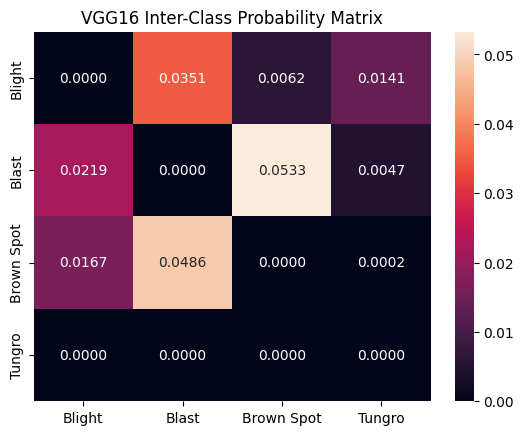

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# VGG16 matrix from output
vgg_matrix = np.array([[0, 0.03509, 0.00620, 0.01413],
                       [0.02189, 0, 0.05329, 0.00474],
                       [0.01665, 0.04861, 0, 0.00019],
                       [0.000004, 0.0000004, 0.00000002, 0]])
class_names = ['Blight', 'Blast', 'Brown Spot', 'Tungro']

sns.heatmap(vgg_matrix, annot=True, fmt='.4f', xticklabels=class_names, yticklabels=class_names)
plt.title('VGG16 Inter-Class Probability Matrix')
plt.savefig('vgg16_heatmap.png')
# Repeat for MobileNetV2